***Imports + Load Dataset***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Personalized_Diet_Recommendations.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5000, 30)


***Basic Dataset Information***

In [2]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

print("\nColumn Names:")
for column in df.columns:
    print("-", column)

Total Rows: 5000
Total Columns: 30

Column Names:
- Patient_ID
- Age
- Gender
- Height_cm
- Weight_kg
- BMI
- Chronic_Disease
- Blood_Pressure_Systolic
- Blood_Pressure_Diastolic
- Cholesterol_Level
- Blood_Sugar_Level
- Genetic_Risk_Factor
- Allergies
- Daily_Steps
- Exercise_Frequency
- Sleep_Hours
- Alcohol_Consumption
- Smoking_Habit
- Dietary_Habits
- Caloric_Intake
- Protein_Intake
- Carbohydrate_Intake
- Fat_Intake
- Preferred_Cuisine
- Food_Aversions
- Recommended_Calories
- Recommended_Protein
- Recommended_Carbs
- Recommended_Fats
- Recommended_Meal_Plan


***Dataset Preview***

In [ ]:
df.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,...,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
0,P00001,56,Other,163,66,24.84,NaN,175,75,219,...,105,179,143,Western,NaN,2150,108,139,145,High-Protein Diet
1,P00002,69,Female,171,114,38.99,NaN,155,72,208,...,69,315,75,Mediterranean,NaN,1527,74,266,80,Balanced Diet
2,P00003,46,Female,172,119,40.22,NaN,137,101,171,...,183,103,148,Western,Sweet,2359,180,145,143,High-Protein Diet
3,P00004,32,Female,197,118,30.41,NaN,148,91,258,...,135,371,120,Western,NaN,2858,137,378,135,High-Protein Diet
4,P00005,60,Female,156,109,44.79,Hypertension,160,109,260,...,167,298,48,Indian,Spicy,1937,166,317,56,High-Protein Diet


***Data Types***

In [ ]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                5000 non-null   object 
 1   Age                       5000 non-null   int64  
 2   Gender                    5000 non-null   object 
 3   Height_cm                 5000 non-null   int64  
 4   Weight_kg                 5000 non-null   int64  
 5   BMI                       5000 non-null   float64
 6   Chronic_Disease           2957 non-null   object 
 7   Blood_Pressure_Systolic   5000 non-null   int64  
 8   Blood_Pressure_Diastolic  5000 non-null   int64  
 9   Cholesterol_Level         5000 non-null   int64  
 10  Blood_Sugar_Level         5000 non-null   int64  
 11  Genetic_Risk_Factor       5000 non-null   object 
 12  Allergies                 1503 non-null   object 
 13  Daily_Steps               5000 non-null  

***Target Selection***

In [ ]:
target = "Caloric_Intake"

print("Target Variable:", target)

print("\nTarget Statistics:")
print(df[target].describe())

Target Variable: Caloric_Intake

Target Statistics:
count    5000.000000
mean     2347.350200
std       659.880146
min      1200.000000
25%      1777.000000
50%      2350.500000
75%      2921.250000
max      3499.000000
Name: Caloric_Intake, dtype: float64


***Separate Numerical and Categorical Features***

In [ ]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Caloric_Intake', 'Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Recommended_Calories', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats']

Categorical Columns:
['Patient_ID', 'Gender', 'Chronic_Disease', 'Genetic_Risk_Factor', 'Allergies', 'Alcohol_Consumption', 'Smoking_Habit', 'Dietary_Habits', 'Preferred_Cuisine', 'Food_Aversions', 'Recommended_Meal_Plan']


***Missing Values Analysis***

In [ ]:
# Missing values count
missing_count = df.isnull().sum()

# Missing values percentage
missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns with missing values
missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    by="Missing Count",
    ascending=False
)

print("MISSING VALUES SUMMARY")
display(missing_summary)

MISSING VALUES SUMMARY


,Missing Count,Missing Percentage
Allergies,3497,69.94
Chronic_Disease,2043,40.86
Food_Aversions,1225,24.50


***Graph — Missing Values***

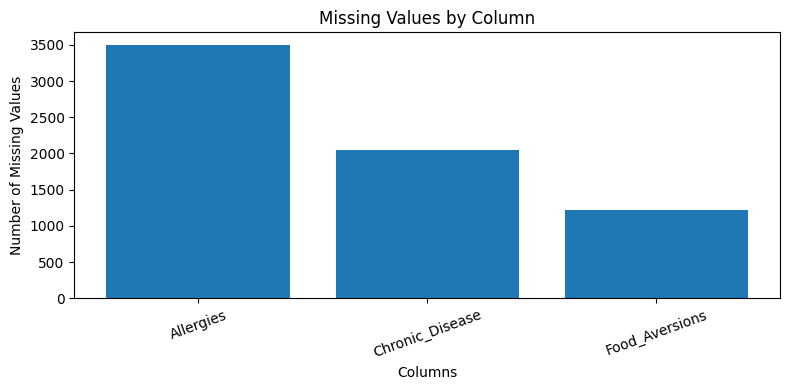

In [ ]:
plt.figure(figsize=(8, 4))

plt.bar(
    missing_summary.index,
    missing_summary["Missing Count"]
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

***Approach 1 — Drop Missing Rows***

In [ ]:
df_drop = df.dropna().copy()

original_rows = len(df)
remaining_rows = len(df_drop)
lost_rows = original_rows - remaining_rows

data_loss_percentage = (
    lost_rows / original_rows
) * 100

print("DROP ROWS EXPERIMENT")
print("--------------------")

print("Original Rows:", original_rows)
print("Remaining Rows:", remaining_rows)
print("Lost Rows:", lost_rows)

print(
    f"Data Loss: {data_loss_percentage:.2f}%"
)

DROP ROWS EXPERIMENT
--------------------
Original Rows: 5000
Remaining Rows: 657
Lost Rows: 4343
Data Loss: 86.86%


***Approach 2 — Mode Imputation***

In [ ]:
df_mode = df.copy()

missing_columns = df_mode.columns[
    df_mode.isnull().any()
]

for column in missing_columns:

    # Find most frequent value
    mode_value = df_mode[column].mode()[0]

    # Fill missing values
    df_mode[column] = df_mode[column].fillna(
        mode_value
    )

print(
    "Missing values after Mode Imputation:",
    df_mode.isnull().sum().sum()
)

Missing values after Mode Imputation: 0


***Approach 3 — Unknown Category***

In [ ]:
df_unknown = df.copy()

for column in df_unknown.columns:

    if df_unknown[column].dtype == "object":

        df_unknown[column] = df_unknown[column].fillna(
            "Unknown"
        )

print(
    "Missing values after Unknown Imputation:",
    df_unknown.isnull().sum().sum()
)

Missing values after Unknown Imputation: 0


***Compare All Three Approaches***

In [ ]:
comparison = pd.DataFrame({
    "Method": [
        "Original",
        "Drop Rows",
        "Mode Imputation",
        "Unknown Category"
    ],

    "Rows Remaining": [
        len(df),
        len(df_drop),
        len(df_mode),
        len(df_unknown)
    ],

    "Missing Values Remaining": [
        df.isnull().sum().sum(),
        df_drop.isnull().sum().sum(),
        df_mode.isnull().sum().sum(),
        df_unknown.isnull().sum().sum()
    ]
})

display(comparison)

,Method,Rows Remaining,Missing Values Remaining
0,Original,5000,6765
1,Drop Rows,657,0
2,Mode Imputation,5000,0
3,Unknown Category,5000,0


***Duplicate Analysis***

In [ ]:
# Count exact duplicate rows

exact_duplicates = df.duplicated().sum()

print("Total Rows:", len(df))
print("Exact Duplicate Rows:", exact_duplicates)

duplicate_percentage = (
    exact_duplicates / len(df)
) * 100

print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Total Rows: 5000
Exact Duplicate Rows: 0
Duplicate Percentage: 0.00%


***Show Duplicate Rows***

In [ ]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Duplicate Records:")
display(duplicate_rows.head())

Duplicate Records:


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,...,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan


***Check Similar Records***

In [ ]:
similar_features = [
    "Age",
    "Gender",
    "Height_cm",
    "Weight_kg",
    "BMI"
]

similar_records = df[
    df.duplicated(
        subset=similar_features,
        keep=False
    )
]

print(
    "Records with similar personal measurements:",
    len(similar_records)
)

display(similar_records.head(10))

Records with similar personal measurements: 32


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,...,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
9,P00010,75,Male,170,114,39.45,Heart Disease,121,70,160,...,166,138,146,Asian,Spicy,1071,157,153,158,Low-Carb Diet
17,P00018,57,Female,183,104,31.05,Diabetes,104,114,282,...,79,232,30,Western,NaN,3018,69,199,43,Balanced Diet
142,P00143,34,Other,178,68,21.46,Hypertension,95,76,187,...,109,390,83,Mediterranean,Salty,2676,109,438,91,Low-Fat Diet
359,P00360,43,Male,180,81,25.00,Heart Disease,140,64,208,...,143,393,57,Mediterranean,Spicy,3101,161,394,50,Low-Carb Diet
465,P00466,70,Other,183,59,17.62,Obesity,155,60,286,...,182,157,32,Asian,Salty,2892,186,182,49,Balanced Diet
482,P00483,38,Male,183,78,23.29,Diabetes,148,101,233,...,80,239,100,Asian,Salty,1215,70,211,100,Low-Fat Diet
525,P00526,75,Male,193,65,17.45,NaN,126,110,269,...,194,339,91,Mediterranean,Sweet,1587,209,383,91,Balanced Diet
788,P00789,24,Male,166,76,27.58,Diabetes,96,105,206,...,107,139,30,Mediterranean,Sweet,3053,120,153,45,Low-Fat Diet
813,P00814,59,Other,180,100,30.86,NaN,128,94,260,...,70,354,96,Mediterranean,Salty,1686,79,386,107,Low-Fat Diet
882,P00883,75,Male,193,65,17.45,Hypertension,130,112,161,...,62,261,69,Western,Sweet,2110,61,267,88,Low-Fat Diet


**Compare Targets for Similar Records**

In [ ]:
if len(similar_records) > 0:

    display(
        similar_records[
            similar_features + ["Caloric_Intake"]
        ].head(15)
    )

,Age,Gender,Height_cm,Weight_kg,BMI,Caloric_Intake
9,75,Male,170,114,39.45,1376
17,57,Female,183,104,31.05,3167
142,34,Other,178,68,21.46,2974
359,43,Male,180,81,25.00,3207
465,70,Other,183,59,17.62,3178
482,38,Male,183,78,23.29,1507
525,75,Male,193,65,17.45,1990
788,24,Male,166,76,27.58,3230
813,59,Other,180,100,30.86,1829
882,75,Male,193,65,17.45,2326


In [ ]:
df_duplicates_clean = df.copy()

***Calculate BMI***

In [ ]:
# Create a copy for validation
df_validation = df.copy()

# Calculate BMI using Height and Weight
df_validation["Calculated_BMI"] = (
    df_validation["Weight_kg"] /
    ((df_validation["Height_cm"] / 100) ** 2)
)

# Calculate difference
df_validation["BMI_Difference"] = (
    df_validation["BMI"] -
    df_validation["Calculated_BMI"]
).abs()

# Show important columns
df_validation[
    [
        "Height_cm",
        "Weight_kg",
        "BMI",
        "Calculated_BMI",
        "BMI_Difference"
    ]
].head()

,Height_cm,Weight_kg,BMI,Calculated_BMI,BMI_Difference
0,163,66,24.84,24.840980,0.000980
1,171,114,38.99,38.986355,0.003645
2,172,119,40.22,40.224446,0.004446
3,197,118,30.41,30.405318,0.004682
4,156,109,44.79,44.789612,0.000388


***BMI Difference Summary***

In [ ]:
print("BMI DIFFERENCE SUMMARY\n")

print(
    df_validation["BMI_Difference"].describe()
)

BMI DIFFERENCE SUMMARY

count    5000.000000
mean        0.002512
std         0.001452
min         0.000000
25%         0.001227
50%         0.002505
75%         0.003755
max         0.005000
Name: BMI_Difference, dtype: float64


***Count Suspicious BMI Values***

In [ ]:
bmi_threshold = 1.0

suspicious_bmi = df_validation[
    df_validation["BMI_Difference"] > bmi_threshold
]

print("Total Records:", len(df_validation))
print(
    f"Records with BMI Difference > {bmi_threshold}:",
    len(suspicious_bmi)
)

percentage = (
    len(suspicious_bmi) /
    len(df_validation)
) * 100

print(
    f"Percentage: {percentage:.2f}%"
)

Total Records: 5000
Records with BMI Difference > 1.0: 0
Percentage: 0.00%


***Show Suspicious BMI Records***

In [ ]:
suspicious_bmi[
    [
        "Height_cm",
        "Weight_kg",
        "BMI",
        "Calculated_BMI",
        "BMI_Difference"
    ]
].head(10)

,Height_cm,Weight_kg,BMI,Calculated_BMI,BMI_Difference


**BMI Visualization**

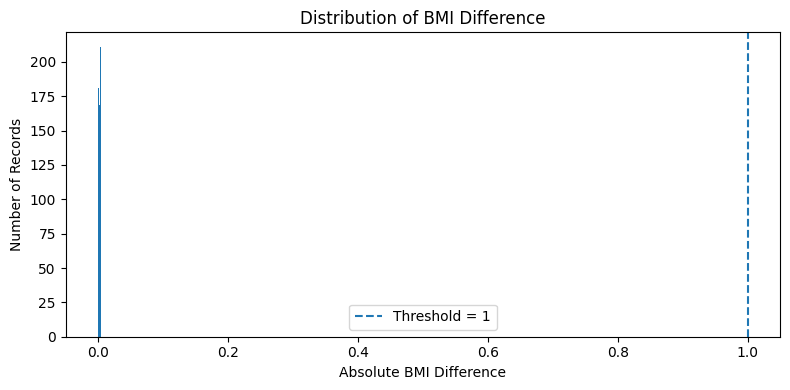

In [ ]:
plt.figure(figsize=(8, 4))

plt.hist(
    df_validation["BMI_Difference"],
    bins=30
)

plt.axvline(
    bmi_threshold,
    linestyle="--",
    label="Threshold = 1"
)

plt.title("Distribution of BMI Difference")
plt.xlabel("Absolute BMI Difference")
plt.ylabel("Number of Records")

plt.legend()
plt.tight_layout()
plt.show()

***Find BP Errors***

In [ ]:
bp_errors = df_validation[
    df_validation["Blood_Pressure_Systolic"]
    <=
    df_validation["Blood_Pressure_Diastolic"]
]

print("Total Records:", len(df_validation))

print(
    "Logical BP Errors:",
    len(bp_errors)
)

bp_error_percentage = (
    len(bp_errors) /
    len(df_validation)
) * 100

print(
    f"Percentage: {bp_error_percentage:.2f}%"
)

Total Records: 5000
Logical BP Errors: 438
Percentage: 8.76%


***Investigate Possible Swapped BP Values***

In [ ]:
df_bp_corrected = df_validation.copy()

# Find invalid rows
invalid_mask = (
    df_bp_corrected["Blood_Pressure_Systolic"]
    <=
    df_bp_corrected["Blood_Pressure_Diastolic"]
)

# Swap systolic and diastolic
temp = df_bp_corrected.loc[
    invalid_mask,
    "Blood_Pressure_Systolic"
].copy()

df_bp_corrected.loc[
    invalid_mask,
    "Blood_Pressure_Systolic"
] = df_bp_corrected.loc[
    invalid_mask,
    "Blood_Pressure_Diastolic"
]

df_bp_corrected.loc[
    invalid_mask,
    "Blood_Pressure_Diastolic"
] = temp

# Check remaining errors
remaining_errors = (
    df_bp_corrected["Blood_Pressure_Systolic"]
    <=
    df_bp_corrected["Blood_Pressure_Diastolic"]
).sum()

print("Original BP Errors:", len(bp_errors))
print("Errors Remaining After Swap:", remaining_errors)

Original BP Errors: 438
Errors Remaining After Swap: 28


***Check Correlation with Target***

In [ ]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation with target
target_correlation = (
    numeric_df.corr()["Caloric_Intake"]
    .abs()
    .sort_values(ascending=False)
)

print("Correlation with Caloric_Intake:\n")
print(target_correlation.head(15))

Correlation with Caloric_Intake:

Caloric_Intake              1.000000
Recommended_Calories        0.985212
Exercise_Frequency          0.026860
Fat_Intake                  0.023663
Recommended_Fats            0.023367
Blood_Pressure_Diastolic    0.019554
Blood_Pressure_Systolic     0.018216
Height_cm                   0.015560
Age                         0.014506
Recommended_Protein         0.008329
BMI                         0.007899
Sleep_Hours                 0.005567
Daily_Steps                 0.005166
Protein_Intake              0.005110
Blood_Sugar_Level           0.004920
Name: Caloric_Intake, dtype: float64


***Visualize Top Correlations***

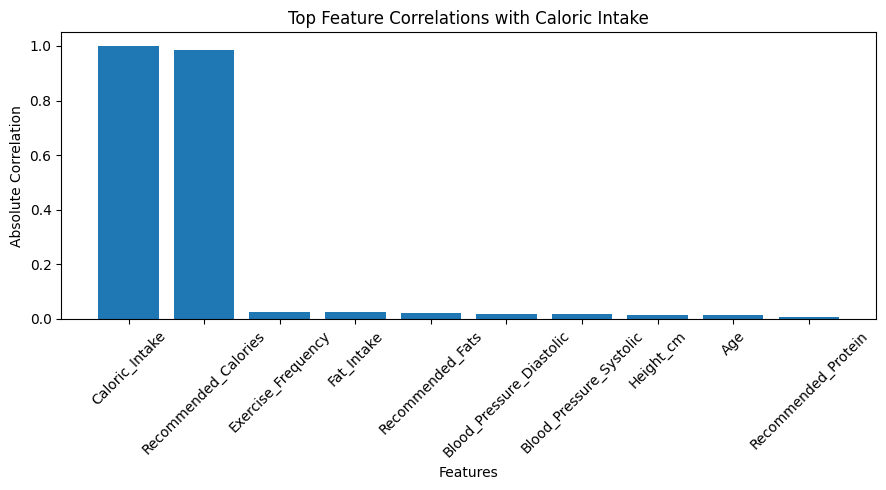

In [ ]:
top_corr = target_correlation.head(10)

plt.figure(figsize=(9, 5))

plt.bar(
    top_corr.index,
    top_corr.values
)

plt.title("Top Feature Correlations with Caloric Intake")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

***Create Two Feature Sets***

In [ ]:
# Model A — With Potential Leakage

X_leak = df.drop(
    columns=["Caloric_Intake"]
)

y = df["Caloric_Intake"]

print("Leakage Experiment Shape:", X_leak.shape)

Leakage Experiment Shape: (5000, 29)


In [ ]:
# Model B — Remove Potential Leakage Features
leakage_features = [
    "Recommended_Calories",

]

In [ ]:
X_clean = df.drop(
    columns=[
        "Caloric_Intake",
        "Patient_ID"
    ] + leakage_features
)

print("Clean Feature Shape:", X_clean.shape)

Clean Feature Shape: (5000, 27)


***First Prepare Missing Values***

In [ ]:
df_experiment = df.copy()

for column in df_experiment.columns:

    if df_experiment[column].isnull().any():

        if df_experiment[column].dtype == "object":

            mode_value = (
                df_experiment[column]
                .mode()[0]
            )

            df_experiment[column] = (
                df_experiment[column]
                .fillna(mode_value)
            )

        else:

            median_value = (
                df_experiment[column]
                .median()
            )

            df_experiment[column] = (
                df_experiment[column]
                .fillna(median_value)
            )

**Function for Leakage Experiment**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_model(X, y):

    # Identify numerical and categorical columns
    numerical_features = X.select_dtypes(
        include=np.number
    ).columns

    categorical_features = X.select_dtypes(
        include="object"
    ).columns

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                "passthrough",
                numerical_features
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            )
        ]
    )

    # Model pipeline
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),

            (
                "model",
                RandomForestRegressor(
                    n_estimators=200,
                    random_state=42
                )
            )
        ]
    )

    # Train-test split
    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )
    )

    # Train model
    model.fit(
        X_train,
        y_train
    )

    # Prediction
    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = mean_squared_error(
        y_test,
        predictions
    ) ** 0.5

    r2 = r2_score(
        y_test,
        predictions
    )

    return mae, rmse, r2

***Run Model A (With Leakage)***

In [ ]:
y = df_experiment["Caloric_Intake"]

X_leak = df_experiment.drop(
    columns=[
        "Caloric_Intake",
        "Patient_ID"
    ]
)

mae_leak, rmse_leak, r2_leak = (
    evaluate_model(X_leak, y)
)

print("MODEL A — WITH POTENTIAL LEAKAGE")

print(f"MAE: {mae_leak:.2f}")
print(f"RMSE: {rmse_leak:.2f}")
print(f"R²: {r2_leak:.4f}")

MODEL A — WITH POTENTIAL LEAKAGE
MAE: 96.72
RMSE: 114.65
R²: 0.9698


***Run Model B (Without Leakage)***

In [ ]:
leakage_features = [
    "Recommended_Calories",

]

X_clean = df_experiment.drop(
    columns=[
        "Caloric_Intake",
        "Patient_ID"
    ] + leakage_features
)

mae_clean, rmse_clean, r2_clean = (
    evaluate_model(X_clean, y)
)

print("MODEL B — WITHOUT LEAKAGE")

print(f"MAE: {mae_clean:.2f}")
print(f"RMSE: {rmse_clean:.2f}")
print(f"R²: {r2_clean:.4f}")

MODEL B — WITHOUT LEAKAGE
MAE: 580.87
RMSE: 667.88
R²: -0.0241


***Compare Results***

In [ ]:
leakage_results = pd.DataFrame({
    "Model": [
        "With Potential Leakage",
        "Without Leakage"
    ],

    "MAE": [
        mae_leak,
        mae_clean
    ],

    "RMSE": [
        rmse_leak,
        rmse_clean
    ],

    "R²": [
        r2_leak,
        r2_clean
    ]
})

display(leakage_results)

,Model,MAE,RMSE,R²
0,With Potential Leakage,96.718995,114.650169,0.969823
1,Without Leakage,580.871180,667.881491,-0.024067


***Visualization***

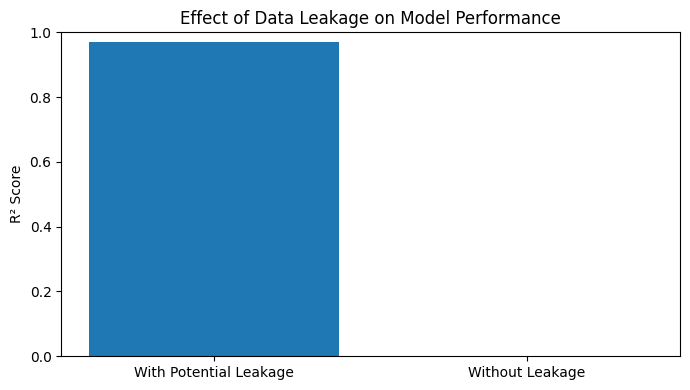

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(
    leakage_results["Model"],
    leakage_results["R²"]
)

plt.title("Effect of Data Leakage on Model Performance")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Create Final X and y

# ============================================================
# FINAL FEATURE SET
# ============================================================

target = "Caloric_Intake"

remove_columns = [
    "Caloric_Intake",
    "Patient_ID",
    "Recommended_Calories",
    "Calorie_Difference"
]

X = df_experiment.drop(
    columns=remove_columns,
    errors="ignore"
)

y = df_experiment[target]

print("Final Feature Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures used for training:")
print(X.columns.tolist())

Final Feature Dataset Shape: (5000, 27)
Target Shape: (5000,)

Features used for training:
['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Chronic_Disease', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Genetic_Risk_Factor', 'Allergies', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Alcohol_Consumption', 'Smoking_Habit', 'Dietary_Habits', 'Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Preferred_Cuisine', 'Food_Aversions', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats', 'Recommended_Meal_Plan']


***Train/Test Split***

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

print("Training Features:", X_train.shape[1])

Training Samples: 4000
Testing Samples: 1000
Training Features: 27


In [ ]:
# Check Numerical and Categorical Features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats']

Categorical Features:
['Gender', 'Chronic_Disease', 'Genetic_Risk_Factor', 'Allergies', 'Alcohol_Consumption', 'Smoking_Habit', 'Dietary_Habits', 'Preferred_Cuisine', 'Food_Aversions', 'Recommended_Meal_Plan']


***Create Preprocessing Pipeline***

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            "passthrough",
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [ ]:
# Train Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

In [ ]:
# Train
final_pipeline.fit(
    X_train,
    y_train
)

print("Model training completed successfully.")

Model training completed successfully.


***Model Evaluation.***

In [ ]:
final_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', 'passthrough',
                                                  ['Age', 'Height_cm',
                                                   'Weight_kg', 'BMI',
                                                   'Blood_Pressure_Systolic',
                                                   'Blood_Pressure_Diastolic',
                                                   'Cholesterol_Level',
                                                   'Blood_Sugar_Level',
                                                   'Daily_Steps',
                                                   'Exercise_Frequency',
                                                   'Sleep_Hours',
                                                   'Protein_Intake',
                                                   'Carbohydrate_Intake',
                                                   'Fat_Intake',
                                                   'Recommended_Protein',
                                                   'Recommended_Carbs',
                                                   'Recommended_Fats']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Chronic_Disease',
                                                   'Genetic_Risk_Factor',
                                                   'Allergies',
                                                   'Alcohol_Consumption',
                                                   'Smoking_Habit',
                                                   'Dietary_Habits',
                                                   'Preferred_Cuisine',
                                                   'Food_Aversions',
                                                   'Recommended_Meal_Plan'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

***Make Predictions***

In [ ]:
# ============================================================
# MODEL PREDICTION
# ============================================================

y_pred = final_pipeline.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


***Calculate Evaluation Metrics***

In [ ]:
# ============================================================
# MODEL EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MODEL PERFORMANCE")
print("-" * 30)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MODEL PERFORMANCE
------------------------------
MAE  : 579.63
RMSE : 666.77
R²   : -0.0206


In [ ]:
print("TARGET SUMMARY")
print(y.describe())

print("\nFINAL FEATURES:")
print(X.columns.tolist())

print("\nDATA TYPES:")
print(X.dtypes)

print("\nMISSING VALUES:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nSHAPE:")
print("X:", X.shape)
print("y:", y.shape)

TARGET SUMMARY
count    5000.000000
mean     2347.350200
std       659.880146
min      1200.000000
25%      1777.000000
50%      2350.500000
75%      2921.250000
max      3499.000000
Name: Caloric_Intake, dtype: float64

FINAL FEATURES:
['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Chronic_Disease', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Genetic_Risk_Factor', 'Allergies', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Alcohol_Consumption', 'Smoking_Habit', 'Dietary_Habits', 'Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Preferred_Cuisine', 'Food_Aversions', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats', 'Recommended_Meal_Plan']

DATA TYPES:
Age                           int64
Gender                       object
Height_cm                     int64
Weight_kg                     int64
BMI                         float64
Chronic_Disease              object
Blood_Pressure_Systolic       int64
Bl

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline model
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(
    X_train,
    y_train
)

baseline_pred = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = mean_squared_error(
    y_test,
    baseline_pred
) ** 0.5

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("BASELINE MODEL PERFORMANCE")
print("-" * 35)
print(f"MAE  : {baseline_mae:.2f}")
print(f"RMSE : {baseline_rmse:.2f}")
print(f"R²   : {baseline_r2:.4f}")

BASELINE MODEL PERFORMANCE
-----------------------------------
MAE  : 575.29
RMSE : 661.01
R²   : -0.0031


In [ ]:
numeric_data = pd.concat(
    [
        X.select_dtypes(include="number"),
        y
    ],
    axis=1
)

correlation = (
    numeric_data
    .corr()["Caloric_Intake"]
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("TOP CORRELATIONS WITH TARGET")
print("-" * 40)

print(correlation.head(15))

TOP CORRELATIONS WITH TARGET
----------------------------------------
Caloric_Intake              1.000000
Exercise_Frequency          0.026860
Fat_Intake                 -0.023663
Recommended_Fats           -0.023367
Blood_Pressure_Diastolic    0.019554
Blood_Pressure_Systolic     0.018216
Height_cm                  -0.015560
Age                         0.014506
Recommended_Protein        -0.008329
BMI                         0.007899
Sleep_Hours                -0.005567
Daily_Steps                 0.005166
Protein_Intake             -0.005110
Blood_Sugar_Level          -0.004920
Carbohydrate_Intake         0.003250
Name: Caloric_Intake, dtype: float64


In [ ]:
final_comparison = pd.DataFrame({
    "Experiment": [
        "Model With Leakage",
        "Model Without Leakage",
        "Baseline Model"
    ],

    "MAE": [
        mae_leak,
        mae,
        baseline_mae
    ],

    "RMSE": [
        rmse_leak,
        rmse,
        baseline_rmse
    ],

    "R2": [
        r2_leak,
        r2,
        baseline_r2
    ]
})

display(final_comparison)

,Experiment,MAE,RMSE,R2
0,Model With Leakage,96.718995,114.650169,0.969823
1,Model Without Leakage,579.630853,666.766085,-0.020649
2,Baseline Model,575.286622,661.006713,-0.003093


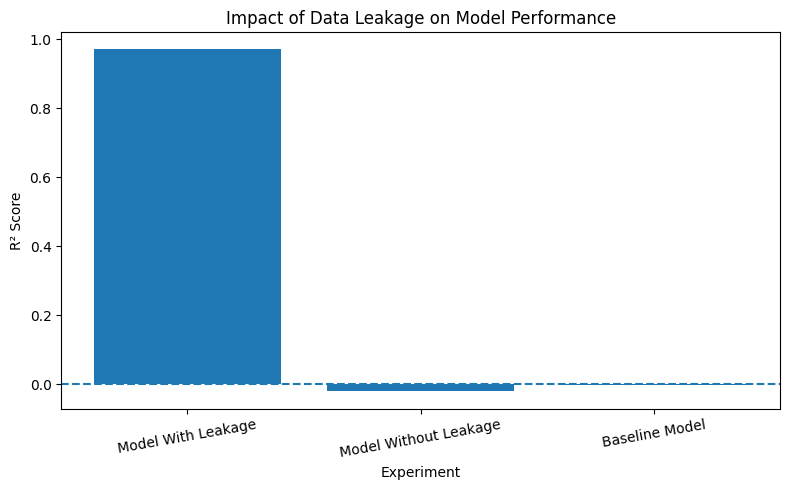

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Experiment"],
    final_comparison["R2"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Impact of Data Leakage on Model Performance")
plt.xlabel("Experiment")
plt.ylabel("R² Score")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# CLEAN MODEL - NO DATA LEAKAGE
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. LOAD CLEAN DATASET
# ============================================================

# Use your dataset that already contains your preprocessing
# (missing values handled + BP/BMI validation done)

df_clean = df.copy()

print("Dataset shape:", df_clean.shape)


# ============================================================
# 2. DEFINE TARGET
# ============================================================

TARGET = "Caloric_Intake"

y = df_clean[TARGET].copy()


# ============================================================
# 3. REMOVE TARGET + NON-PREDICTIVE / LEAKAGE FEATURES
# ============================================================

features_to_remove = [

    # Target
    "Caloric_Intake",

    # Identifier
    "Patient_ID",

    # Direct leakage
    "Recommended_Calories",

    # Leakage-derived features
    "Calorie_Difference",

    # Experimental derived features
    "Calculated_Calories"
]

# Remove only columns that actually exist
features_to_remove = [
    col for col in features_to_remove
    if col in df_clean.columns
]

X = df_clean.drop(
    columns=features_to_remove
)

print("\nRemoved Features:")
print(features_to_remove)

print("\nFinal Features:")
print(X.columns.tolist())

print("\nTotal Features:", X.shape[1])


# ============================================================
# 4. CHECK FOR MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nDataset Shape:")
print("X:", X.shape)
print("y:", y.shape)


# ============================================================
# 5. IDENTIFY NUMERICAL + CATEGORICAL COLUMNS
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain Size:", X_train.shape)
print("Test Size:", X_test.shape)


# ============================================================
# 7. PREPROCESSING PIPELINE
# ============================================================

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 8. CLEAN MODEL
# ============================================================

clean_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 9. COMPLETE PIPELINE
# ============================================================

clean_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            clean_model
        )
    ]
)


# ============================================================
# 10. TRAIN MODEL
# ============================================================

clean_pipeline.fit(
    X_train,
    y_train
)

print("\nClean model trained successfully.")


# ============================================================
# 11. PREDICTION
# ============================================================

y_pred_clean = clean_pipeline.predict(
    X_test
)


# ============================================================
# 12. EVALUATION
# ============================================================

clean_mae = mean_absolute_error(
    y_test,
    y_pred_clean
)

clean_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_clean
    )
)

clean_r2 = r2_score(
    y_test,
    y_pred_clean
)


print("\n" + "=" * 45)
print("CLEAN MODEL PERFORMANCE")
print("=" * 45)

print(f"MAE  : {clean_mae:.2f}")
print(f"RMSE : {clean_rmse:.2f}")
print(f"R²   : {clean_r2:.4f}")


# ============================================================
# 13. SAVE CLEAN MODEL
# ============================================================

joblib.dump(
    clean_pipeline,
    "clean_model.pkl"
)

print("\nModel saved successfully as:")
print("clean_model.pkl")

Dataset shape: (5000, 30)

Removed Features:
['Caloric_Intake', 'Patient_ID', 'Recommended_Calories']

Final Features:
['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Chronic_Disease', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Genetic_Risk_Factor', 'Allergies', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Alcohol_Consumption', 'Smoking_Habit', 'Dietary_Habits', 'Protein_Intake', 'Carbohydrate_Intake', 'Fat_Intake', 'Preferred_Cuisine', 'Food_Aversions', 'Recommended_Protein', 'Recommended_Carbs', 'Recommended_Fats', 'Recommended_Meal_Plan']

Total Features: 27

Missing Values:
Chronic_Disease    2043
Allergies          3497
Food_Aversions     1225
dtype: int64

Dataset Shape:
X: (5000, 27)
y: (5000,)

Numerical Features:
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Daily_Steps', 'Exercise_Frequency', 'Sleep_Hours', 'Protein_In

In [4]:
from google.colab import files

files.download("clean_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>